In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set Datalist

In [2]:
file_path = r'C:\Users\sharif\Desktop\Final5.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""METHANOL"").F","STREAMS(""METHANOL"").T","STREAMS(""METHANOL"").P","STREAMS(""FV"").F","STREAMS(""FV"").T","STREAMS(""FV"").P","STREAMS(""FV"").Zmn(""1-BUT-01"")","STREAMS(""FV"").Zmn(""ISOBU-01"")","STREAMS(""P1"").F","STREAMS(""P1"").T",...,"BLOCKS(""RDCOLUMN"").Stage(4).T","BLOCKS(""RDCOLUMN"").Stage(5).T","BLOCKS(""RDCOLUMN"").Stage(6).T","BLOCKS(""RDCOLUMN"").Stage(7).T","BLOCKS(""RDCOLUMN"").Stage(8).T","BLOCKS(""RDCOLUMN"").Stage(9).T","BLOCKS(""RDCOLUMN"").Stage(10).T","BLOCKS(""RDCOLUMN"").Stage(11).T","STREAMS(""P1"").Zmn(""1-BUT-01"")","STREAMS(""P2"").Zmn(""METHY-01"")"
0,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
1,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
2,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
3,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
4,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3313,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974


In [3]:
df.describe

<bound method NDFrame.describe of        STREAMS("METHANOL").F  STREAMS("METHANOL").T  STREAMS("METHANOL").P  \
0                    712.082                  46.85                1.01325   
1                    712.082                  46.85                1.01325   
2                    712.082                  46.85                1.01325   
3                    712.082                  46.85                1.01325   
4                    712.082                  46.85                1.01325   
...                      ...                    ...                    ...   
12648                718.993                  46.85                1.01325   
12649                718.993                  46.85                1.01325   
12650                718.993                  46.85                1.01325   
12651                718.993                  46.85                1.01325   
12652                718.993                  46.85                1.01325   

       STREAMS("FV").F  STREA

# PreProcessing

In [4]:
x = df.drop(['STREAMS("P2").Zmn("METHY-01")','STREAMS("P1").Zmn("1-BUT-01")'] , axis=1).values
y = df[['STREAMS("P2").Zmn("METHY-01")','STREAMS("P1").Zmn("1-BUT-01")']].values

In [5]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()
x = scaler_x.fit_transform(x)
y = scaler_y.fit_transform(y)

In [6]:
sequence_length = 10
def create_sequences(x, y, seq_len):
    x_seq, y_seq = [], []
    for i in range(len(x) - seq_len + 1):
        x_seq.append(x[i:i + seq_len])
        y_seq.append(y[i + seq_len - 1])
    return np.array(x_seq), np.array(y_seq)

In [7]:
x_seq, y_seq = create_sequences(x, y, sequence_length)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x_seq, y_seq, test_size=0.2, random_state=42)

# Model Definition

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, Add, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

def tcn_block(inputs, num_filters, kernel_size, dilation_rate, dropout_rate):

    if inputs.shape[-1] != num_filters:
        residual = Conv1D(filters=num_filters, kernel_size=1, padding="same")(inputs)
    else:
        residual = inputs

    x = Conv1D(filters=num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate,
               padding="causal", activation=None)(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(rate=dropout_rate)(x)

    x = Conv1D(filters=num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate,
               padding="causal", activation=None)(x)
    x = BatchNormalization()(x)

    x = Add()([residual, x])
    return ReLU()(x)

def build_tcn_model(input_shape, num_filters=64, kernel_size=3, num_blocks=3, dilation_rate=2, dropout_rate=0.2):
   
    inputs = Input(shape=input_shape)
    x = inputs

    for i in range(num_blocks):
        x = tcn_block(x, num_filters=num_filters, kernel_size=kernel_size,
                      dilation_rate=dilation_rate**i, dropout_rate=dropout_rate)
        
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(output_units)(x)

    return Model(inputs=inputs, outputs=outputs)

In [10]:
input_shape = (sequence_length, x_train.shape[2])
output_units = y_train.shape[1]

In [11]:
model = build_tcn_model(input_shape, num_filters=64, kernel_size=3, num_blocks=4, dilation_rate=2, dropout_rate=0.3)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 36)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 64)    │      6,976 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 10, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 64)    │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 10, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 10, 64)    │      2,368 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 64)    │          0 │ conv1d[0][0],     │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 10, 64)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 10, 64)    │     12,352 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 10, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 64)    │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 10, 64)    │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 64)    │          0 │ re_lu_1[0][0],    │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 10, 64)    │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 10, 64)    │     12,352 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 10, 64)    │          0 │ batch_normalizat

 Total params: 139,010 (543.01 KB)

 Trainable params: 137,986 (539.01 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=60, restore_best_weights=True)

In [13]:
history = model.fit(x_train, y_train,
                    validation_data=(x_test, y_test),
                    epochs=100,
                    batch_size=32,
                    callbacks=[early_stopping])

Epoch 1/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 1.0245 - mae: 0.5089 - val_loss: 0.0792 - val_mae: 0.1380
Epoch 2/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.2136 - mae: 0.2061 - val_loss: 0.0694 - val_mae: 0.1224
Epoch 3/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1423 - mae: 0.1639 - val_loss: 0.0719 - val_mae: 0.1204
Epoch 4/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1245 - mae: 0.1520 - val_loss: 0.0536 - val_mae: 0.0997
Epoch 5/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1195 - mae: 0.1451 - val_loss: 0.0691 - val_mae: 0.1197
Epoch 6/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1000 - mae: 0.1412 - val_loss: 0.0520 - val_mae: 0.1187
Epoch 7/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1063 - mae: 0.1414 - val_loss: 0.0291 - val_mae: 0.0863
Epoch 8/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0850 - mae: 0.1269 - val_loss: 0.0286 - val_mae: 0.0845
Epoch 9/100
317/317 ━━━━━━━━━━━━━━━━━━━

In [14]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038 - mae: 0.0352
Test Loss: 0.0034495920408517122, Test MAE: 0.03497529402375221


In [15]:
y_pred = model.predict(x_test)

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [16]:
mse_list = []
mae_list = []
r2_list = []

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error (y_test , y_pred)
mae = mean_absolute_error (y_test , y_pred)
r2 = r2_score (y_test , y_pred)

mse_list.append(mse)
mae_list.append(mae)
r2_list.append(r2)

In [18]:
mean_mse = np.mean (mse_list)
mean_mae = np.mean (mae_list)
mean_r2 = np.mean (r2_list)

print("Mean Mean Squared Error (MSE) on Training Data :" , mean_mse)
print("Mean Mean Absolute Error (MAE) on Training Data :" , mean_mae)
print("Mean R2 Score on Training Data :" , mean_r2)

Mean Mean Squared Error (MSE) on Training Data : 0.0034495924151642697
Mean Mean Absolute Error (MAE) on Training Data : 0.03497528748192737
Mean R2 Score on Training Data : 0.996480726748665


In [19]:
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 2))
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 2))

In [20]:
results = pd.DataFrame({
    'Actual MoleFractionTX': y_test_original[:, 0],
    'Predicted MoleFractionTX': y_pred_original[:, 0],
    'Actual MoleFractionHX': y_test_original[:, 1],
    'Predicted MoleFractionHX': y_pred_original[:, 1]
})
results.head()

,Actual MoleFractionTX,Predicted MoleFractionTX,Actual MoleFractionHX,Predicted MoleFractionHX
0,0.965976,0.963808,0.936313,0.935838
1,0.958321,0.958591,0.937094,0.937056
2,0.970800,0.973362,0.953000,0.952935
3,0.965893,0.963777,0.936821,0.936952
4,0.960773,0.961191,0.952008,0.951397


Total number of samples: 2529
Plotting first 5000 samples.


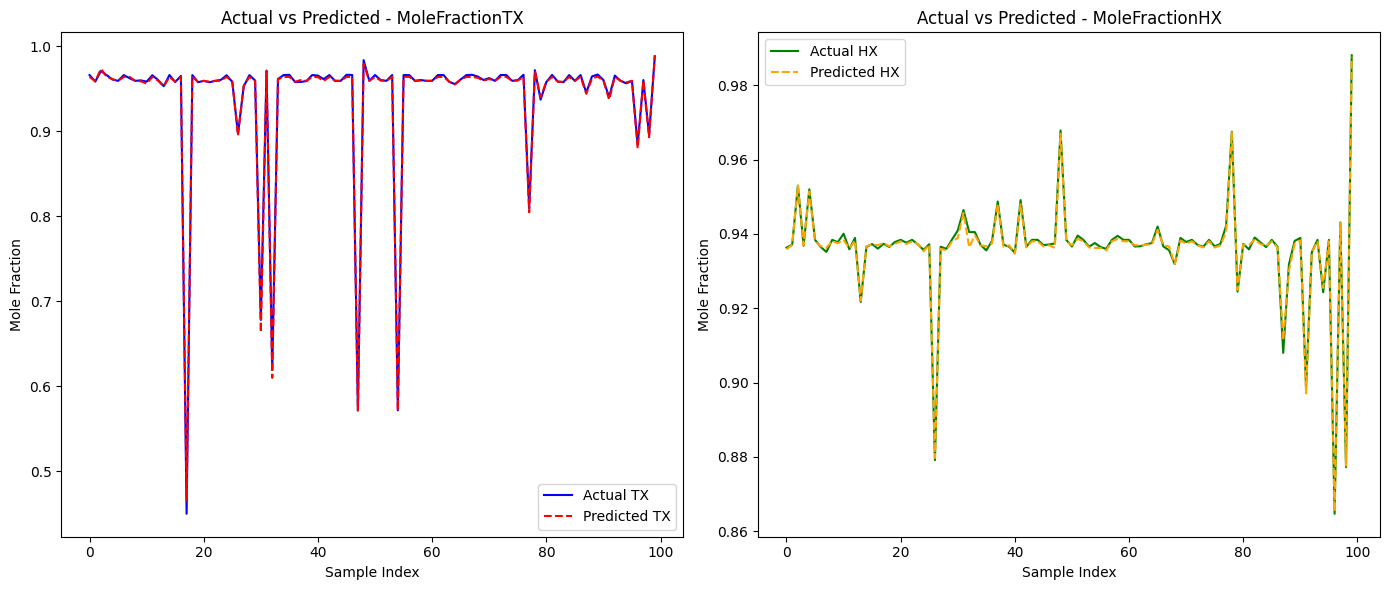

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# بررسی تعداد کل داده‌ها
num_samples = len(results)
print(f"Total number of samples: {num_samples}")

# اگر داده‌ها بیشتر از 5000 بودند، فقط 5000 تای اول را انتخاب کن
if num_samples >= 100:
    subset = results.iloc[:100]
    print("Plotting first 5000 samples.")
else:
    subset = results
    print("Plotting all available samples.")

# رسم نمودار
plt.figure(figsize=(14, 6))

# MoleFractionTX
plt.subplot(1, 2, 1)
plt.plot(subset['Actual MoleFractionTX'].values, label='Actual TX', color='blue')
plt.plot(subset['Predicted MoleFractionTX'].values, label='Predicted TX', color='red', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionTX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

# MoleFractionHX
plt.subplot(1, 2, 2)
plt.plot(subset['Actual MoleFractionHX'].values, label='Actual HX', color='green')
plt.plot(subset['Predicted MoleFractionHX'].values, label='Predicted HX', color='orange', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionHX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    return (within_tol / len(y_true)) * 100

In [23]:
tolerances = [0.005, 0.002, 0.001]

# دو خروجی داریم: TX (ستون 0) و HX (ستون 1)
tx_true = y_test_original[:, 0]
tx_pred = y_pred_original[:, 0]
hx_true = y_test_original[:, 1]
hx_pred = y_pred_original[:, 1]

tx_results = []
hx_results = []

In [24]:
for tol in tolerances:
    tx_acc = percentage_within_tolerance(tx_true, tx_pred, tolerance=tol)
    hx_acc = percentage_within_tolerance(hx_true, hx_pred, tolerance=tol)
    tx_results.append(tx_acc)
    hx_results.append(hx_acc)
    print(f"TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {tx_acc:.2f}%")
    print(f"HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {hx_acc:.2f}%")
    print('-'*50)

TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 95.29%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 99.60%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 60.70%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 96.60%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 46.38%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 84.14%
--------------------------------------------------


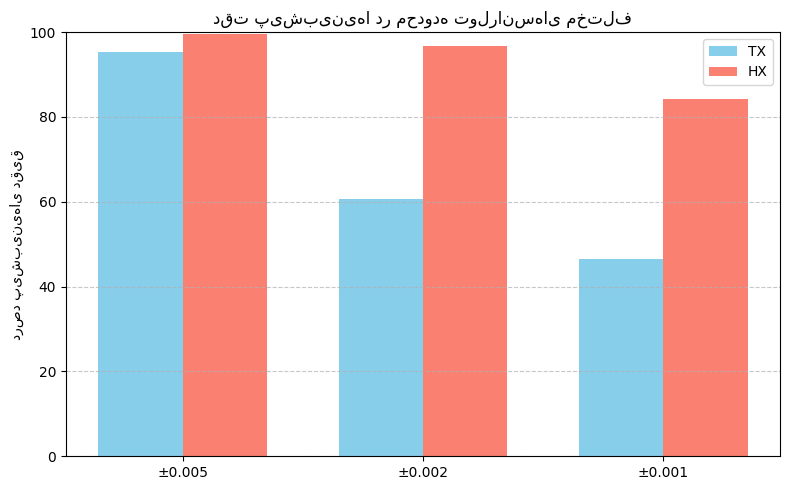

In [25]:
import matplotlib.pyplot as plt
x_labels = [f"±{tol}" for tol in tolerances]
x = np.arange(len(tolerances))

plt.figure(figsize=(8, 5))
bar_width = 0.35

plt.bar(x - bar_width/2, tx_results, width=bar_width, label='TX', color='skyblue')
plt.bar(x + bar_width/2, hx_results, width=bar_width, label='HX', color='salmon')

plt.xticks(x, x_labels)
plt.ylim(0, 100)
plt.ylabel("درصد پیش‌بینی‌های دقیق")
plt.title("دقت پیش‌بینی‌ها در محدوده تولرانس‌های مختلف")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

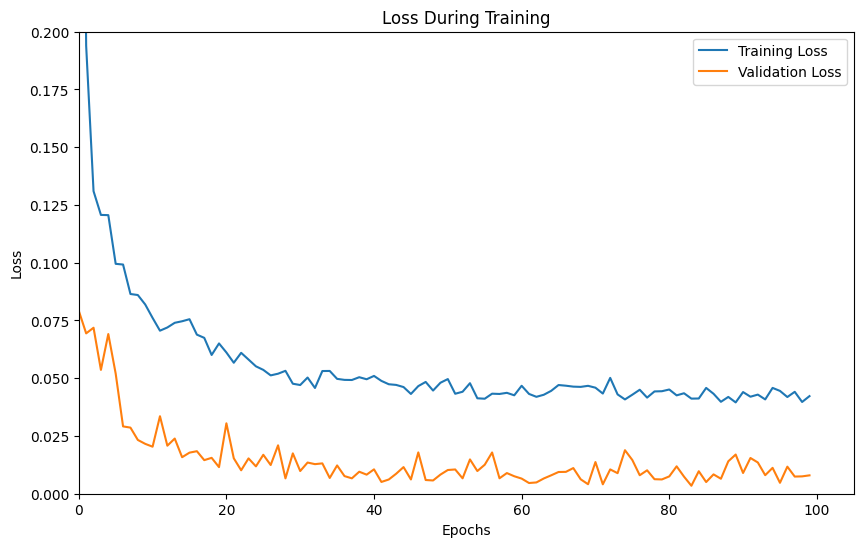

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.xlim(0,105)
plt.ylim(0,0.2)
plt.show()

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import torch
from sklearn.metrics import mean_squared_error, r2_score

d:\ArshadProjectVSCode\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
y_test_np = y_test.reshape(-1)
y_pred_np = y_pred.reshape(-1)

# 📌 5. SHAP Analysis

In [29]:
from sklearn.base import BaseEstimator, RegressorMixin

class KerasModelWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, sequence_length, n_features):
        self.model = model
        self.sequence_length = sequence_length
        self.n_features = n_features

    def fit(self, X, y=None):
        return self  # dummy fit for compatibility

    def predict(self, X):
        X_seq = X.reshape(-1, self.sequence_length, self.n_features)
        return self.model.predict(X_seq)[:, 0]

In [30]:
n_features = x_test.shape[2]
wrapped_model = KerasModelWrapper(model=model, sequence_length=sequence_length, n_features=n_features)

x_test_flat = x_test.reshape(x_test.shape[0], -1)

In [31]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    wrapped_model, 
    x_test_flat, 
    y_test[:, 0], 
    scoring='neg_mean_squared_error', 
    n_repeats=10, 
    random_state=42
)

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
80/80 ━━━━━━━━━━━━━━━━━━━

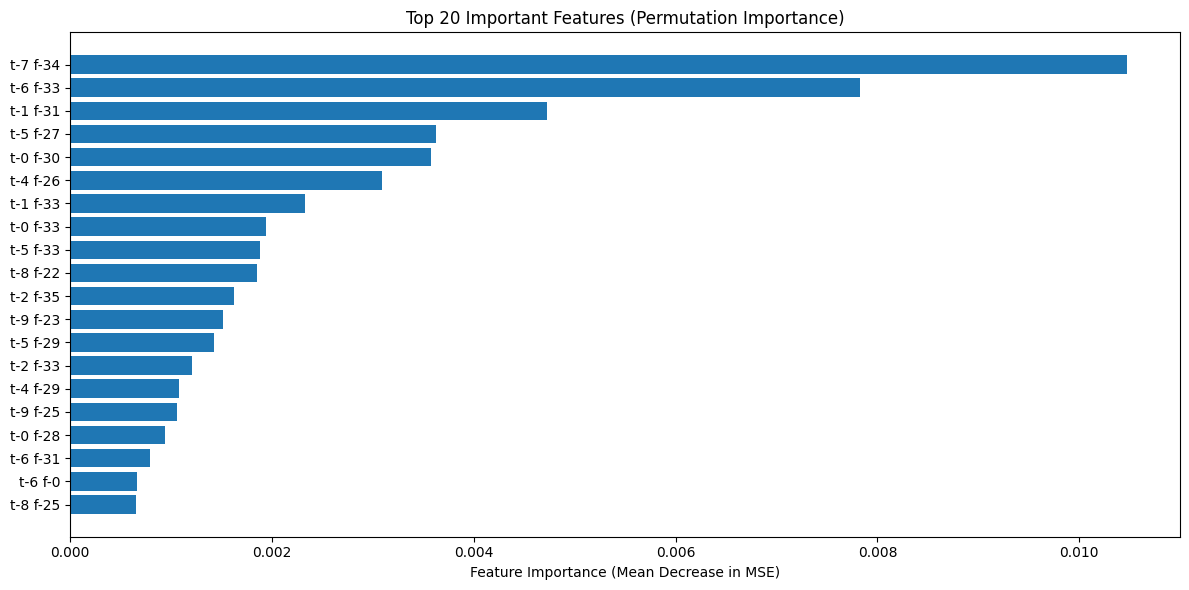

In [32]:

plt.figure(figsize=(12, 6))
sorted_idx = result.importances_mean.argsort()[::-1][:20]
plt.barh(np.array(range(len(sorted_idx))), result.importances_mean[sorted_idx])
plt.yticks(range(len(sorted_idx)), [f"t-{i % sequence_length} f-{i // sequence_length}" for i in sorted_idx])
plt.xlabel("Feature Importance (Mean Decrease in MSE)")
plt.title("Top 20 Important Features (Permutation Importance)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()